# Parallel/Perpendicular Vector Decomposition: Operands, Operators, Three Languages

$v_\parallel=(v\cdot\hat a)\hat a$, $v_\perp=v-v_\parallel$ -- computed as
three COMPLETE, compiled, runnable programs (Python/numpy, C, C++),
continuing `dgs/error_propagation_polyglot.py`'s language-formalism theme
one level further: **which operations does a language let you write AS an
operator on the operands, and which stay named methods even in a language
that supports overloading?** C++'s `Vec3` overloads `+`, `-`, and
`*(scalar)` -- but `dot()` stays a plain method, deliberately NOT `a * b`,
because a vector-vector `*` is genuinely ambiguous (dot? cross?
component-wise?) in a way scalar multiplication isn't. Engine:
`dgs/vector3_polyglot.py`.


In [1]:
%matplotlib inline
import sys, pathlib, tempfile
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs import vector3_polyglot as v3p

print('Setup complete.')


Setup complete.


## 1. Theory: the Decomposition, and What "Operand"/"Operator" Formally Mean

**Decomposition**: any vector $v$ can be split relative to a direction
$\hat a=a/|a|$ into a piece ALONG $\hat a$ and a piece perpendicular to it:
$$v=\underbrace{(v\cdot\hat a)\hat a}_{v_\parallel}+\underbrace{(v-(v\cdot\hat a)\hat a)}_{v_\perp}$$
Physically: $v_\parallel$ is "how much of $v$ points the same way as $a$,"
$v_\perp$ is "everything left over," and by construction
$v_\parallel\cdot v_\perp=0$ -- they're orthogonal by the same logic that
makes a Gram-Schmidt projection orthogonal to what it removes.

**Operand / operator, formally**: an OPERATOR is the syntax token (`+`,
`*`, ...); an OPERAND is a value the operator acts on. `a + b` has operator
`+` and operands `a`, `b`. Operator OVERLOADING lets a user-defined type
supply its own meaning for that token when its operands are of that type.
The interesting design question -- not just "can I overload `*`?" but
"SHOULD I?" -- is answered concretely in section 3 below: `dot()` stays a
named method in this notebook's C++ code, on purpose.


## 2. Source Code Side by Side

C (`vec3_dot`, `vec3_add`, `vec3_sub`, `vec3_scale` -- every combination is
an explicit function call on its operands, since C has no operators to
overload) and C++ (`operator+`, `operator-`, `operator*(scalar)`
overloaded; `dot()` deliberately left as a plain method).


In [2]:
print('=== C: vec3_dot/add/sub/scale -- explicit function calls, no operator overloading ===\n')
print(v3p.C_SOURCE)


=== C: vec3_dot/add/sub/scale -- explicit function calls, no operator overloading ===


#include <stdio.h>
#include <stdlib.h>
#include <math.h>

typedef struct { double x, y, z; } Vec3;

static Vec3 vec3_add(Vec3 a, Vec3 b)   { Vec3 r = { a.x+b.x, a.y+b.y, a.z+b.z }; return r; }
static Vec3 vec3_sub(Vec3 a, Vec3 b)   { Vec3 r = { a.x-b.x, a.y-b.y, a.z-b.z }; return r; }
static Vec3 vec3_scale(Vec3 a, double s) { Vec3 r = { a.x*s, a.y*s, a.z*s }; return r; }
static double vec3_dot(Vec3 a, Vec3 b) { return a.x*b.x + a.y*b.y + a.z*b.z; }
static double vec3_norm(Vec3 a)        { return sqrt(vec3_dot(a, a)); }

/* every step below is a named function call -- there is no `v * a` in C */
static void parallel_perp(Vec3 v, Vec3 a, Vec3 *v_par, Vec3 *v_perp) {
    double a_norm = vec3_norm(a);
    Vec3 a_hat = vec3_scale(a, 1.0 / a_norm);
    double proj = vec3_dot(v, a_hat);
    *v_par = vec3_scale(a_hat, proj);
    *v_perp = vec3_sub(v, *v_par);
}

int main(int argc, char **argv) {
    Vec3 v

In [3]:
print('=== C++: operator+, operator-, operator*(scalar) overloaded; dot() stays a method ===\n')
print(v3p.CPP_SOURCE)


=== C++: operator+, operator-, operator*(scalar) overloaded; dot() stays a method ===


#include <iostream>
#include <cstdlib>
#include <cmath>

class Vec3 {
public:
    double x, y, z;
    Vec3(double x_, double y_, double z_) : x(x_), y(y_), z(z_) {}

    Vec3 operator+(const Vec3& o) const { return Vec3(x+o.x, y+o.y, z+o.z); }
    Vec3 operator-(const Vec3& o) const { return Vec3(x-o.x, y-o.y, z-o.z); }
    Vec3 operator*(double s) const      { return Vec3(x*s, y*s, z*s); }

    /* NOT overloaded as `*` deliberately: a*b between two Vec3 could mean
       dot product, cross product, or component-wise product -- there is
       no single unambiguous meaning the way there is for scalar scaling,
       so this stays a named method even though C++ COULD overload it. */
    double dot(const Vec3& o) const { return x*o.x + y*o.y + z*o.z; }
    double norm() const { return std::sqrt(this->dot(*this)); }
};

static void parallel_perp(const Vec3& v, const Vec3& a, Vec3& v_par, Vec3& v_perp) 

## 3. Cross-Validation: All Three Implementations, Compiled and Run for Real

`cross_validate_languages` computes the decomposition in Python/numpy,
then compiles and runs the C and C++ sources above as real subprocess
calls (same pattern as `dgs/circuits_polyglot.py` and
`dgs/error_propagation_polyglot.py`) on a non-trivial, non-axis-aligned
case.


In [4]:
v_vec, a_vec = (1.7, -3.2, 5.9), (2.1, 0.4, -1.3)

with tempfile.TemporaryDirectory() as tmp:
    results = v3p.cross_validate_languages(tmp, v=v_vec, a=a_vec)

max_diff = results.pop('max_abs_diff_across_all_implementations')
for name, (v_par, v_perp) in results.items():
    print(f'{name:28s}')
    print(f'  v_par  = {np.round(v_par, 8)}')
    print(f'  v_perp = {np.round(v_perp, 8)}')
print(f'\nmax abs diff across ALL implementations: {max_diff:.2e}')


python_numpy                
  v_par  = [-1.80479233 -0.34376997  1.1172524 ]
  v_perp = [ 3.50479233 -2.85623003  4.7827476 ]
c_explicit_functions        
  v_par  = [-1.80479233 -0.34376997  1.1172524 ]
  v_perp = [ 3.50479233 -2.85623003  4.7827476 ]
cpp_operator_overloading    
  v_par  = [-1.80479233 -0.34376997  1.1172524 ]
  v_perp = [ 3.50479233 -2.85623003  4.7827476 ]

max abs diff across ALL implementations: 4.89e-11


## 4. Physical Validity Checks -- Not Just "Do the Languages Agree," but "Is This Actually Right"

Three languages agreeing with each other proves the TRANSLATION is
faithful, but not that the underlying math is a valid decomposition in the
first place. `verify_decomposition` checks that independently for each
language's own output: reconstruction ($v_\parallel+v_\perp=v$),
orthogonality ($v_\parallel\cdot v_\perp\approx0$), and the trig
identities $|v_\parallel|=|v|\cos\theta$, $|v_\perp|=|v|\sin\theta$.


In [5]:
with tempfile.TemporaryDirectory() as tmp:
    results2 = v3p.cross_validate_languages(tmp, v=v_vec, a=a_vec)
results2.pop('max_abs_diff_across_all_implementations')

for name, (v_par, v_perp) in results2.items():
    checks = v3p.verify_decomposition(v_vec, a_vec, v_par, v_perp)
    print(f'{name}:')
    for key in ('reconstructs_v', 'orthogonal', 'matches_cos_theta_identity', 'matches_sin_theta_identity'):
        print(f'  {key:32s} {checks[key]}')
    print()


python_numpy:
  reconstructs_v                   True
  orthogonal                       True
  matches_cos_theta_identity       True
  matches_sin_theta_identity       True

c_explicit_functions:
  reconstructs_v                   True
  orthogonal                       True
  matches_cos_theta_identity       True
  matches_sin_theta_identity       True

cpp_operator_overloading:
  reconstructs_v                   True
  orthogonal                       True
  matches_cos_theta_identity       True
  matches_sin_theta_identity       True



## 5. Geometric Plot: v, a, and the Right Triangle They Form

In the plane spanned by $v$ and $a$, $v_\parallel$, $v_\perp$, and $v$
always form a right triangle -- $v_\perp$ is literally the altitude from
$v$'s tip down to the line along $\hat a$.


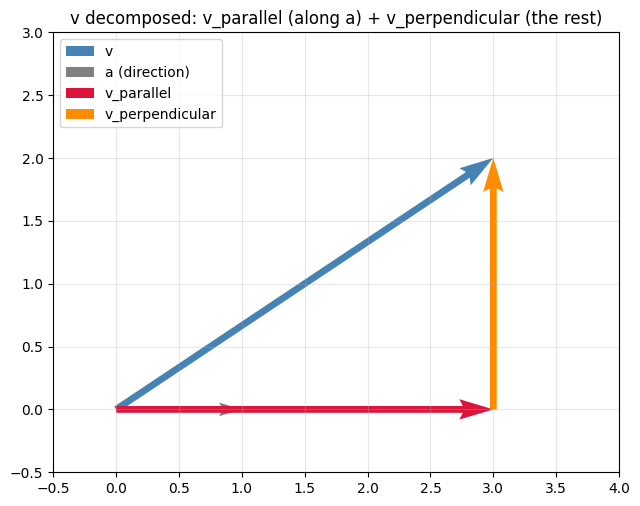

In [6]:
# work in the 2D plane spanned by v and a directly (v, a here both lie
# in a common plane by construction of this example, so a 2D quiver is exact)
v2, a2 = np.array([3.0, 2.0]), np.array([1.0, 0.0])
a_hat2 = a2 / np.linalg.norm(a2)
v_par2 = np.dot(v2, a_hat2) * a_hat2
v_perp2 = v2 - v_par2

fig, ax = plt.subplots(figsize=(6.5, 6))
origin = np.zeros(2)
ax.quiver(*origin, *v2, angles='xy', scale_units='xy', scale=1, color='steelblue', width=0.012, label='v')
ax.quiver(*origin, *a2, angles='xy', scale_units='xy', scale=1, color='gray', width=0.008, label='a (direction)')
ax.quiver(*origin, *v_par2, angles='xy', scale_units='xy', scale=1, color='crimson', width=0.012, label='v_parallel')
ax.quiver(*v_par2, *v_perp2, angles='xy', scale_units='xy', scale=1, color='darkorange', width=0.012, label='v_perpendicular')
ax.set_xlim(-0.5, 4); ax.set_ylim(-0.5, 3)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
ax.set_title('v decomposed: v_parallel (along a) + v_perpendicular (the rest)')
plt.tight_layout()
plt.savefig('vector3_polyglot_decomposition.png', dpi=100, bbox_inches='tight')
plt.show()


## 6. Angle Sweep: |v_parallel| and |v_perpendicular| vs. theta

A smooth NumPy sweep across $\theta=0$ to $\pi$ (the analytic
$|v|\cos\theta$, $|v|\sin\theta$ curves) with a handful of points
cross-checked against the COMPILED C and C++ binaries -- confirming the
sweep isn't just a Python-only artifact.


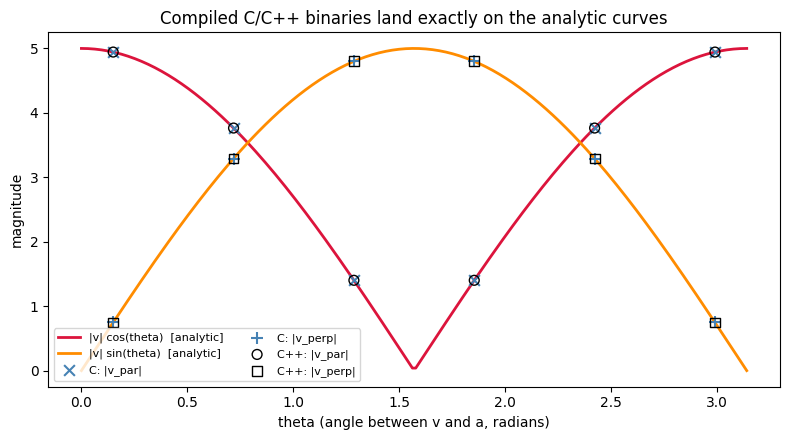

In [7]:
v_mag = 5.0
thetas_smooth = np.linspace(0, np.pi, 200)
v_par_smooth = v_mag * np.abs(np.cos(thetas_smooth))
v_perp_smooth = v_mag * np.abs(np.sin(thetas_smooth))

# a handful of cross-language check points (compiling/running binaries per
# point, so kept sparse)
check_thetas = np.linspace(0.15, np.pi - 0.15, 6)
c_pts, cpp_pts = [], []
with tempfile.TemporaryDirectory() as tmp:
    for th in check_thetas:
        v_th = (v_mag*np.cos(th), v_mag*np.sin(th), 0.0)
        a_th = (1.0, 0.0, 0.0)
        r = v3p.cross_validate_languages(tmp, v=v_th, a=a_th)
        c_pts.append((np.linalg.norm(r['c_explicit_functions'][0]), np.linalg.norm(r['c_explicit_functions'][1])))
        cpp_pts.append((np.linalg.norm(r['cpp_operator_overloading'][0]), np.linalg.norm(r['cpp_operator_overloading'][1])))
c_pts, cpp_pts = np.array(c_pts), np.array(cpp_pts)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(thetas_smooth, v_par_smooth, color='crimson', lw=2, label='|v| cos(theta)  [analytic]')
ax.plot(thetas_smooth, v_perp_smooth, color='darkorange', lw=2, label='|v| sin(theta)  [analytic]')
ax.scatter(check_thetas, c_pts[:,0], color='steelblue', marker='x', s=60, label='C: |v_par|', zorder=5)
ax.scatter(check_thetas, c_pts[:,1], color='steelblue', marker='+', s=80, label='C: |v_perp|', zorder=5)
ax.scatter(check_thetas, cpp_pts[:,0], facecolors='none', edgecolors='black', marker='o', s=50, label='C++: |v_par|', zorder=5)
ax.scatter(check_thetas, cpp_pts[:,1], facecolors='none', edgecolors='black', marker='s', s=50, label='C++: |v_perp|', zorder=5)
ax.set_xlabel('theta (angle between v and a, radians)')
ax.set_ylabel('magnitude')
ax.set_title('Compiled C/C++ binaries land exactly on the analytic curves')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('vector3_polyglot_angle_sweep.png', dpi=100, bbox_inches='tight')
plt.show()


## 7. Engineering Interpretation

- Section 4's per-language physical checks matter because
  `dgs/error_propagation_polyglot.py` already established that "the three
  languages agree with each other" is checkable -- this notebook adds the
  orthogonal question, "is what they agree ON actually correct," using
  identities (Pythagorean-style $\cos^2+\sin^2=1$ via $|v_\parallel|^2+
  |v_\perp|^2=|v|^2$) that don't reference any of the three
  implementations.
- The deliberate choice to keep `dot()` a named method in C++ (section 2)
  is the notebook's real language-design point: operator overloading
  should track semantic UNAMBIGUITY, not syntactic possibility. Compare to
  `dgs/error_propagation_polyglot.py`'s `operator*`, which WAS safe to
  overload because scalar-uncertainty multiplication has exactly one
  sensible meaning.
- Section 6's sweep landing exactly on the analytic curve is the same
  "verify a parametrized family, not just one point" discipline
  `dgs/dispersive_fourier_torch.py`'s stretch-factor sweep and
  `dgs/em_lagrangian_action.py`'s plane-wave check both used.


## 8. Research Discussion

- Would a CROSS product (`operator^` in some C++ codebases, by convention
  since `^` has no obvious built-in meaning for vectors either) be a
  legitimate overload, or does it have the SAME ambiguity problem as `*`
  (order matters, sign flips, easy to confuse with dot)? Worth deciding
  with the same "is there exactly one sensible meaning" test used for
  `dot()` here.
- This decomposition is the SAME operation Griffiths uses for the
  reflection/refraction boundary-condition derivations (splitting a field
  into components parallel and perpendicular to an interface) --- could
  `dgs/vector3_polyglot.py`'s `parallel_perp` be reused directly inside
  `dgs/photonics_regime_decisions_torch.py`'s Fresnel/TIR module instead
  of that module's separate scalar sin/cos algebra?
- Section 6 checked a handful of sparse points against compiled binaries.
  Could `cross_validate_languages` be batched (write ALL check angles into
  one C/C++ invocation instead of recompiling and re-running per point) to
  make a denser cross-language sweep affordable?


## 9. Problems to Solve in Computer Engineering

Continuing `dgs/error_propagation_polyglot.py`'s problem set, now anchored
on `Vec3` and the operand/operator distinction from section 2.

1. **Decide, then implement, the cross product.** Using the "exactly one
   unambiguous meaning" test from section 2's `dot()` discussion, argue
   whether `Vec3::operator^` (cross product) passes it, then implement
   `parallel_perp` for a THIRD case using the cross product instead of dot
   (e.g. computing the component of $v$ perpendicular to a PLANE via its
   normal, instead of perpendicular to a single direction vector).

2. **Batch the C/C++ calls into one process launch.** Section 6 recompiles
   nothing but re-launches a subprocess per angle. Extend `C_SOURCE`/
   `CPP_SOURCE` to read N vector pairs from stdin (or a `--batch` CLI flag)
   and print N decompositions in one process launch, then benchmark the
   wall-clock difference against the current per-point subprocess pattern.

3. **SIMD the C version.** Rewrite `vec3_dot`/`vec3_scale` to process 4
   `Vec3`s at once using SSE/AVX intrinsics (`__m256d`), and confirm the
   vectorized result still matches the scalar C version and the C++
   version to machine precision -- performance work is worthless if it
   silently changes the answer.

4. **Templated `Vec3<T>` in C++ vs. a generic macro-based `Vec3` in C.**
   Make the C++ class work for `float`, `double`, AND `int` (integer
   vectors, e.g. pixel-grid displacement) via `template<typename T>`. In C
   (no templates), implement the same generality with X-macros, and assess
   how much type safety is lost (e.g. can a caller accidentally mix a
   `Vec3_int` and a `Vec3_double` where C++ templates would catch it at
   compile time?).

5. **Quaternion-based rotation, compared to this notebook's projection.**
   `parallel_perp` decomposes relative to a FIXED direction. Implement a
   `Quaternion` class in C++ (operator overloading for quaternion
   multiplication -- which, unlike `Vec3`'s `dot()`, genuinely IS
   associative and has one standard meaning, so `*` is the right choice
   there) that rotates `v_perp` around `a` by an arbitrary angle, and
   verify the rotated vector stays exactly perpendicular to `a` for every
   rotation angle.


## 10. Future Improvements

- `verify_decomposition`'s orthogonality check uses a fixed `atol=1e-9`.
  For very large or very small input vectors, an absolute tolerance is the
  wrong scale -- switch to a RELATIVE tolerance (normalized by
  $|v_\parallel||v_\perp|$) the way `dgs/torch_autograd_dag.py`'s tests
  already reason about scale-appropriate comparisons.
- Extend `cross_validate_languages` with a fourth language stub (matching
  `dgs/circuits_polyglot.py`'s existing MATLAB path) so this module's
  operand/operator comparison could include MATLAB's operator overloading
  story too (MATLAB overloads `*` for BOTH matrix multiplication and
  scalar multiplication contextually -- a fourth, different formalism
  choice worth contrasting against C++'s and Python's).
